In [392]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from PIL import Image,ImageDraw
import numpy as np
import random
import matplotlib.pyplot as plt

In [393]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 32
EMBED_DIM = 64
ATTN_HEAD = 4
BATCH_SIZE = 32
EPOCHS = 50
LR = 3e-4
TEMPERATURE = 0.07


In [394]:
print(device)

cpu


In [395]:
colors = ['red','green','blue','yellow','orange','pink','brown','gray','purple']
shapes = ['circle','rectangle','triangle']
positions = ['left','center','right','top','bottom','top-left','top-right','bottom-right','bottom-left']

In [396]:
total_combinations = len(colors)*len(shapes)*len(positions)
print(f"Total Possible image-text pairs: {total_combinations}")

Total Possible image-text pairs: 243


In [397]:
from PIL import Image, ImageDraw

def draw_image(color, shape, position, img_size=200):
    img = Image.new('RGB', (img_size, img_size), 'white')
    draw = ImageDraw.Draw(img)

    margin = 2
    unit = (img_size - 2 * margin) // 4  

    
    x0, y0, x1, y1 = margin + unit, margin + unit, margin + 3*unit, margin + 3*unit

    
    if 'top' in position:
        y0, y1 = margin, margin + 2*unit
    elif 'bottom' in position:
        y0, y1 = img_size - margin - 2*unit, img_size - margin

    
    if 'left' in position:
        x0, x1 = margin, margin + 2*unit
    elif 'right' in position:
        x0, x1 = img_size - margin - 2*unit, img_size - margin

    
    coords = [x0, y0, x1, y1]
    
    if shape == 'rectangle':
        draw.rectangle(coords, fill=color, outline='black')
    elif shape == 'circle':
       
        draw.ellipse(coords, fill=color, outline='black')
    elif shape == 'triangle':
        
        points = [(x0, y1), (x1, y1), (x0 + (x1 - x0) // 2, y0)]
        draw.polygon(points, fill=color, outline='black')

    return img

In [398]:
class ShapeDataset(Dataset):
    def __init__(self):
        self.images = []
        self.captions = []

        for c in colors:
            for s in shapes:
                for p in positions:
                    img = draw_image(c,s,p,img_size=IMG_SIZE)
                    self.images.append(torch.from_numpy(np.asarray(img)).permute(2,0,1).float()/255.0)
                    # didnt understood what is permute
                    self.captions.append(f"{c} {s} {p}")
        self.vocab,self.w2i = self.build_vocab(self.captions)

    def build_vocab(self,texts):
        words = sorted({w for t in texts for w in t.split()})
        vocab = ['[CLS]']+ words
        w2i = {w:i for i,w in enumerate(vocab)}
        return vocab,w2i

    def encode_texts(self,text):
        tokens = [self.w2i['[CLS]']] + [self.w2i[w] for w in text.split()]
        return torch.tensor(tokens,dtype=torch.long)

    def __getitem__(self,idx):
        return self.images[idx],self.encode_texts(self.captions[idx])
    def __len__(self):
        return len(self.images)


In [399]:
full_ds = ShapeDataset()
VOCAB_SZIE = len(full_ds.vocab)
print(VOCAB_SZIE)
print(full_ds.vocab)

22
['[CLS]', 'blue', 'bottom', 'bottom-left', 'bottom-right', 'brown', 'center', 'circle', 'gray', 'green', 'left', 'orange', 'pink', 'purple', 'rectangle', 'red', 'right', 'top', 'top-left', 'top-right', 'triangle', 'yellow']


In [400]:
train_size = int(0.8*len(full_ds))
val_size = len(full_ds) - train_size
train_ds,val_ds = torch.utils.data.random_split(full_ds,[train_size,val_size])


In [401]:
print(f"Train Size {len(train_ds)}")
print(f"Validation Size {len(val_ds)}")

Train Size 194
Validation Size 49


In [402]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [403]:
for images, captions in train_loader:
    print(f"Image batch shape: {images.shape}")    # Expected: [32, 3, IMG_SIZE, IMG_SIZE]
    print(f"Caption batch shape: {captions.shape}") # Expected: [32, Max_Seq_Len]
    break

Image batch shape: torch.Size([32, 3, 32, 32])
Caption batch shape: torch.Size([32, 4])


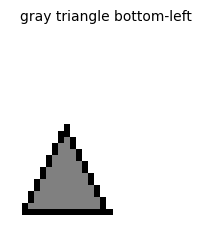

In [404]:

# 1. Get a batch
imgs, encoded_caps = next(iter(train_loader))

# 2. Pick a random index
idx = random.randint(0, len(imgs) - 1)

# 3. Fix the typo: .permute instead of .premute
# We move channels back to the end (1, 2, 0) for matplotlib
img = (imgs[idx].permute(1, 2, 0).numpy() * 255).astype(np.uint8)

# 4. Decode the caption
caption_tokens = encoded_caps[idx].tolist()
# Filter out [CLS] and [PAD] if you ever add it, then join
words = [full_ds.vocab[t] for t in caption_tokens if full_ds.vocab[t] != '[CLS]']
caption_text = " ".join(words)

# 5. Display
plt.figure(figsize=(2.5, 2.5))
plt.imshow(img)
plt.title(caption_text, fontsize=10)
plt.axis('off')
plt.show()

In [405]:
class ImageEncoder(nn.Module):
    def __init__(self,embed_dim = EMBED_DIM):
        super().__init__()
        self.convolutions = nn.Sequential(
            nn.Conv2d(3,32,3,2,1),
            nn.ReLU(),
            nn.Conv2d(32,64,3,2,1),
            nn.ReLU(),
            nn.Conv2d(64,128,3,2,1),
            nn.ReLU(),
            nn.Conv2d(128,256,3,2,1),
            nn.ReLU(),
        )

        self.projection = nn.Linear(256,embed_dim)
        self.layernorm1 = nn.LayerNorm(embed_dim)

    def forward(self,x):
        x = self.convolutions(x)
        x = x.mean(dim = [2,3])
        x = self.projection(x)
        x = F.normalize(self.layernorm1(x),dim=-1)

        return x

In [406]:
class TextEncoder(nn.Module):
    def __init__(self,embed_dim = EMBED_DIM,num_heads = ATTN_HEAD,vocab_size = VOCAB_SZIE):
        super().__init__()

        self.token_embed = nn.Embedding(vocab_size,embed_dim)
        self.position_embed = nn.Embedding(vocab_size,embed_dim)
        self.mha = nn.MultiheadAttention(embed_dim,num_heads,batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.projection = nn.Linear(embed_dim,embed_dim)
    def forward(self,toks):
        N,L = toks.shape
        position_emb_ids = torch.arange(L,device=toks.device).unsqueeze(0).expand(N,L)
        x = self.token_embed(toks) + self.position_embed(position_emb_ids)
        context_vec,_ = self.mha(x,x,x)
        cls_token = context_vec[:,0,:]
        projection = self.projection(cls_token)
        output = F.normalize(self.norm(projection),dim = -1)

        return output


In [407]:
def clip_loss(img_emb,txt_emb,temperature = TEMPERATURE):
    logits = img_emb @ txt_emb.T / temperature
    targets = torch.arange(img_emb.size(0),device=img_emb.device)
    loss_i = F.cross_entropy(logits,targets)
    loss_t = F.cross_entropy(logits.T,targets)
    return ((loss_i+loss_t)/2.0)

In [408]:
img_encoder = ImageEncoder().to(device)
text_enc = TextEncoder().to(device)
params = list(img_encoder.parameters()) + list(text_enc.parameters())
optimizer = torch.optim.AdamW(params,lr=LR)

In [409]:
def show_image(t,title=None):
    img = (t.permute(1,2,0).numpy()*255).astype(np.uint8)
    plt.figure(figsize=(2,2))
    plt.axis('off')
    if title: plt.title(title,fontsize=8)
    plt.imshow(img)
    plt.show()

Sample Image caption: blue triangle right


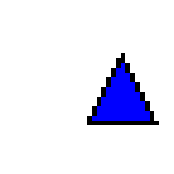

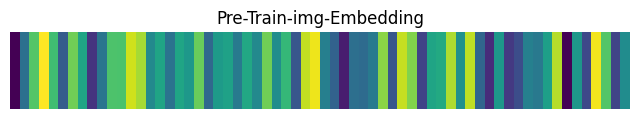

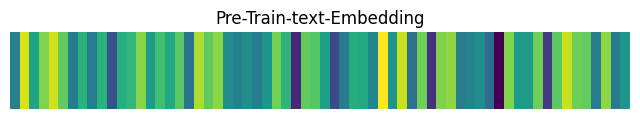

In [410]:
img_encoder.eval()
text_enc.eval()

with torch.no_grad():
    random_idx = random.randrange(len(full_ds))
    sample_img, sample_toks = full_ds[random_idx]
    sample_cap = full_ds.captions[random_idx]
    sample_img = sample_img.unsqueeze(0).to(device)
    sample_toks = sample_toks.unsqueeze(0).to(device)
    pre_train_img_embed = img_encoder(sample_img).squeeze(0).cpu().numpy()
    pre_train_text_embed = text_enc(sample_toks).squeeze(0).cpu().numpy()

print(f"Sample Image caption: {sample_cap}")
show_image(sample_img.squeeze(0).cpu())

def plot_embeddings(embddings,title):
    plt.figure(figsize=(8,1))
    plt.imshow(embddings.reshape(1,-1),aspect='auto',cmap='viridis')
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_embeddings(pre_train_img_embed,"Pre-Train-img-Embedding")
plot_embeddings(pre_train_text_embed,"Pre-Train-text-Embedding")

In [411]:
best_val = float('inf')

for epoch in range(1, EPOCHS + 1):

    # -------- TRAIN --------
    img_encoder.train()
    text_enc.train()

    total = 0.0

    for imgs, toks in train_loader:
        imgs = imgs.to(device)
        toks = toks.to(device)

        optimizer.zero_grad(set_to_none=True)

        img_emb = img_encoder(imgs)
        text_emb = text_enc(toks)

        loss = clip_loss(img_emb, text_emb)

        loss.backward()
        optimizer.step()

        total += loss.item() * imgs.size(0)

    train_loss = total / len(train_loader.dataset)

    # -------- VALIDATION --------
    img_encoder.eval()
    text_enc.eval()

    vtotal = 0.0
    n = 0

    with torch.no_grad():
        for imgs, toks in val_loader:
            imgs = imgs.to(device)
            toks = toks.to(device)

            img_emb = img_encoder(imgs)
            text_emb = text_enc(toks)

            loss = clip_loss(img_emb, text_emb)

            vtotal += loss.item() * imgs.size(0)
            n += imgs.size(0)

    val_loss = vtotal / n

    # -------- PRINT --------
    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )


# in clip loss the temperature plays the biggest role as it increases the difference or say the maximizes the contrast if
# two of then are not likely same not any lr or 

Epoch 001/50 | Train Loss: 3.4614 | Val Loss: 3.2058
Epoch 002/50 | Train Loss: 3.3679 | Val Loss: 3.0726
Epoch 003/50 | Train Loss: 3.0578 | Val Loss: 2.0550
Epoch 004/50 | Train Loss: 1.8428 | Val Loss: 1.4460
Epoch 005/50 | Train Loss: 1.3631 | Val Loss: 1.4236
Epoch 006/50 | Train Loss: 1.2007 | Val Loss: 0.9826
Epoch 007/50 | Train Loss: 0.9952 | Val Loss: 0.6512
Epoch 008/50 | Train Loss: 0.6228 | Val Loss: 0.5061
Epoch 009/50 | Train Loss: 0.4946 | Val Loss: 0.3816
Epoch 010/50 | Train Loss: 0.3506 | Val Loss: 0.2682
Epoch 011/50 | Train Loss: 0.3121 | Val Loss: 0.4002
Epoch 012/50 | Train Loss: 0.3016 | Val Loss: 0.3385
Epoch 013/50 | Train Loss: 0.3077 | Val Loss: 0.2055
Epoch 014/50 | Train Loss: 0.1837 | Val Loss: 0.2021
Epoch 015/50 | Train Loss: 0.2096 | Val Loss: 0.1508
Epoch 016/50 | Train Loss: 0.1642 | Val Loss: 0.1585
Epoch 017/50 | Train Loss: 0.1229 | Val Loss: 0.1616
Epoch 018/50 | Train Loss: 0.1243 | Val Loss: 0.1491
Epoch 019/50 | Train Loss: 0.1302 | Val Loss: 

Sample Image caption: blue circle top-left


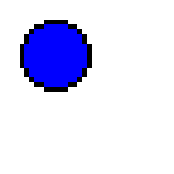

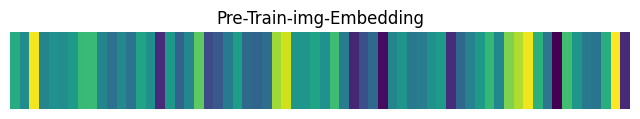

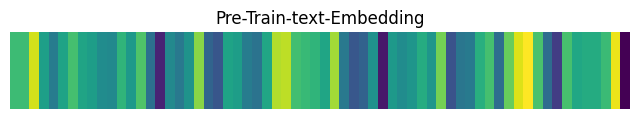

In [412]:
img_encoder.eval()
text_enc.eval()

with torch.no_grad():
    random_idx = random.randrange(len(full_ds))
    sample_img, sample_toks = full_ds[random_idx]
    sample_cap = full_ds.captions[random_idx]
    sample_img = sample_img.unsqueeze(0).to(device)
    sample_toks = sample_toks.unsqueeze(0).to(device)
    pre_train_img_embed = img_encoder(sample_img).squeeze(0).cpu().numpy()
    pre_train_text_embed = text_enc(sample_toks).squeeze(0).cpu().numpy()

print(f"Sample Image caption: {sample_cap}")
show_image(sample_img.squeeze(0).cpu())

def plot_embeddings(embddings,title):
    plt.figure(figsize=(8,1))
    plt.imshow(embddings.reshape(1,-1),aspect='auto',cmap='viridis')
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_embeddings(pre_train_img_embed,"Pre-Train-img-Embedding")
plot_embeddings(pre_train_text_embed,"Pre-Train-text-Embedding")

In [413]:
img_encoder.eval()
text_enc.eval()

all_img_emb = []
all_text_emb = []
all_caps = []

with torch.no_grad():
    for idx, (img, toks) in enumerate(full_ds):

        cap = full_ds.captions[idx]

        img = img.unsqueeze(0).to(device)
        toks = toks.unsqueeze(0).to(device)

        img_emb = img_encoder(img)
        text_emb = text_enc(toks)

        all_img_emb.append(img_emb.cpu())
        all_text_emb.append(text_emb.cpu())
        all_caps.append(cap)

all_img_emb = torch.cat(all_img_emb)
all_text_emb = torch.cat(all_text_emb)

In [414]:
def search_caption(img_tensor):

    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        img_emb = img_encoder(img_tensor).cpu()

    sims = img_emb @ all_text_emb.T

    best_idx = sims.argmax().item()

    print("Predicted caption:", all_caps[best_idx])

    show_image(img_tensor.squeeze(0).cpu())

Predicted caption: red rectangle top


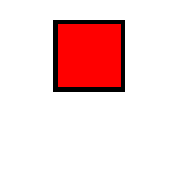

In [419]:
img, toks = full_ds[12]
search_caption(img)

In [416]:
def search_image_topk(query, k=5):

    tokens = full_ds.encode_texts(query).unsqueeze(0).to(device)

    with torch.no_grad():
        text_emb = text_enc(tokens).cpu()

    sims = (text_emb @ all_img_emb.T).squeeze()

    topk = sims.topk(k)

    for rank, idx in enumerate(topk.indices):
        print(f"Rank {rank+1}: {all_caps[idx]}")
        show_image(full_ds.images[idx])

Rank 1: red circle top


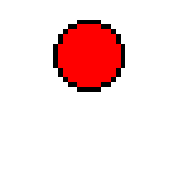

Rank 2: red rectangle top


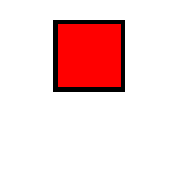

Rank 3: orange circle top


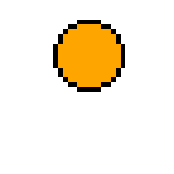

In [423]:
search_image_topk("red circle top", k=3)